# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [1]:
# TODO: Import all necessary libraries here

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style="whitegrid")

# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [2]:
# TODO: Load regression dataset

reg_path ="insurance.csv"

df_reg = pd.read_csv(reg_path)
print("Regression dataset shape:", df_reg.shape)
print("Columns:", list(df_reg.columns))

target_reg = "charges" if "charges" in df_reg.columns else df_reg.columns[-1]
print("Target variable:", target_reg)

df_reg.head()

Regression dataset shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Target variable: charges


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


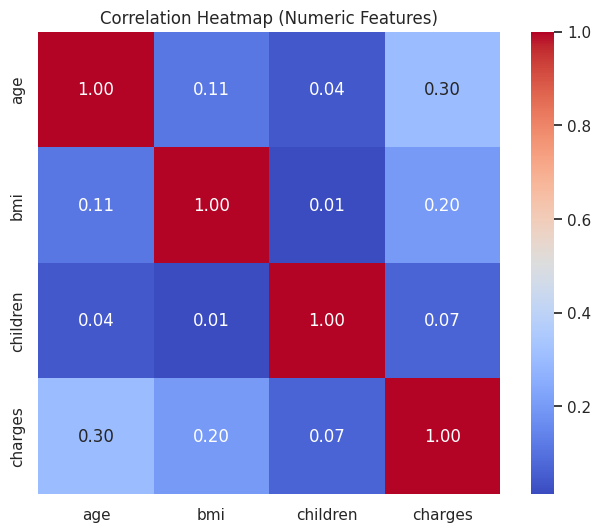

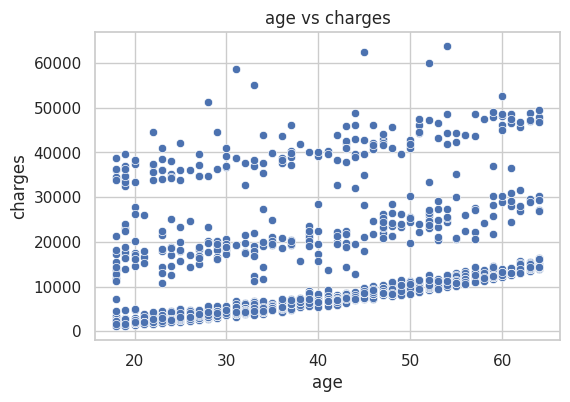

EDA note: The heatmap highlights linear relationships among numeric features and the target.


In [3]:
# TODO: Perform EDA
df_reg.describe(include="all").T

num_corr = df_reg.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

numeric_cols = df_reg.select_dtypes(include=[np.number]).columns.tolist()
feature_to_plot = next((c for c in numeric_cols if c != target_reg), None)
if feature_to_plot is not None:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=df_reg[feature_to_plot], y=df_reg[target_reg])
    plt.title(f"{feature_to_plot} vs {target_reg}")
    plt.xlabel(feature_to_plot)
    plt.ylabel(target_reg)
    plt.show()

print("EDA note: The heatmap highlights linear relationships among numeric features and the target.")

## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [4]:
# TODO: Prepare features
X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns
cat_cols_reg = X_reg.select_dtypes(exclude=[np.number]).columns

preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_reg),
    ],
    remainder="drop",
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Train shape:", X_train_reg.shape, "Test shape:", X_test_reg.shape)
print("Scaling applied to numeric features; categorical features are one-hot encoded.")


Train shape: (1070, 6) Test shape: (268, 6)
Scaling applied to numeric features; categorical features are one-hot encoded.


## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [7]:
# TODO: Multiple Linear Regression

lin_reg_model = Pipeline(
    steps=[("preprocess", preprocess_reg), ("model", LinearRegression())]
)
lin_reg_model.fit(X_train_reg, y_train_reg)

lin_pred = lin_reg_model.predict(X_test_reg)
# Calculate MSE first, then take the square root for RMSE
lin_rmse = np.sqrt(mean_squared_error(y_test_reg, lin_pred))
lin_mae = mean_absolute_error(y_test_reg, lin_pred)
lin_r2 = r2_score(y_test_reg, lin_pred)

metrics_reg_linear = {"RMSE": lin_rmse, "MAE": lin_mae, "R2": lin_r2}
print("Linear Regression Metrics:", metrics_reg_linear)

Linear Regression Metrics: {'RMSE': np.float64(5796.284659276274), 'MAE': 4181.194473753652, 'R2': 0.7835929767120722}


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [9]:
# TODO: Polynomial Regression

poly_num = Pipeline(
    steps=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
    ]
)
preprocess_reg_poly = ColumnTransformer(
    transformers=[
        ("num", poly_num, num_cols_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_reg),
    ],
    remainder="drop",
)

poly_model = Pipeline(
    steps=[("preprocess", preprocess_reg_poly), ("model", LinearRegression())]
)
poly_model.fit(X_train_reg, y_train_reg)

poly_pred = poly_model.predict(X_test_reg)
# Calculate MSE first, then take the square root for RMSE
poly_rmse = np.sqrt(mean_squared_error(y_test_reg, poly_pred))
poly_mae = mean_absolute_error(y_test_reg, poly_pred)
poly_r2 = r2_score(y_test_reg, poly_pred)

metrics_reg_poly = {"RMSE": poly_rmse, "MAE": poly_mae, "R2": poly_r2}
print("Polynomial Regression Metrics:", metrics_reg_poly)
print("Comparison vs Linear:", metrics_reg_linear)

Polynomial Regression Metrics: {'RMSE': np.float64(5841.280185905569), 'MAE': 4254.274826829182, 'R2': 0.7802200772760515}
Comparison vs Linear: {'RMSE': np.float64(5796.284659276274), 'MAE': 4181.194473753652, 'R2': 0.7835929767120722}


## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [13]:
# TODO: Support Vector Regression

svr_model = Pipeline(steps=[("preprocess", preprocess_reg), ("model", SVR(kernel="rbf"))])
svr_model.fit(X_train_reg, y_train_reg)

svr_pred = svr_model.predict(X_test_reg)
svr_rmse = np.sqrt(mean_squared_error(y_test_reg, svr_pred))
svr_mae = mean_absolute_error(y_test_reg, svr_pred)
svr_r2 = r2_score(y_test_reg, svr_pred)

metrics_reg_svr = {"RMSE": svr_rmse, "MAE": svr_mae, "R2": svr_r2}
print("SVR Metrics:", metrics_reg_svr)
print("Kernel choice: RBF handles non-linear patterns without manual feature expansion.")

SVR Metrics: {'RMSE': np.float64(12892.023995416239), 'MAE': 8605.845654288496, 'R2': -0.0705677341215194}
Kernel choice: RBF handles non-linear patterns without manual feature expansion.


## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [14]:
# TODO: Random Forest Regressor

rf_reg_model = Pipeline(
    steps=[
        ("preprocess", preprocess_reg),
        ("model", RandomForestRegressor(n_estimators=200, random_state=42)),
    ]
)
rf_reg_model.fit(X_train_reg, y_train_reg)

rf_pred = rf_reg_model.predict(X_test_reg)
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_pred))
rf_mae = mean_absolute_error(y_test_reg, rf_pred)
rf_r2 = r2_score(y_test_reg, rf_pred)

metrics_reg_rf = {"RMSE": rf_rmse, "MAE": rf_mae, "R2": rf_r2}
print("Random Forest Regression Metrics:", metrics_reg_rf)

Random Forest Regression Metrics: {'RMSE': np.float64(4587.539558854192), 'MAE': 2529.343571291683, 'R2': 0.8644399925086196}


# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [15]:
# TODO: Load classification dataset

clf_path = "loan_data.csv"

df_clf = pd.read_csv(clf_path)
print("Classification dataset shape:", df_clf.shape)
print("Columns:", list(df_clf.columns))

candidate_targets = [
    "loan_status",
    "Loan_Status",
    "target",
    "label",
    "approved",
    "Approved",
    "Status",
]
target_clf = next((c for c in candidate_targets if c in df_clf.columns), df_clf.columns[-1])

print("Target variable:", target_clf)
class_counts = df_clf[target_clf].value_counts()
print(class_counts)

if len(class_counts) > 1:
    imbalance_ratio = class_counts.max() / class_counts.min()
    if imbalance_ratio > 1.5:
        print("Imbalance note: The classes are moderately imbalanced.")
    else:
        print("Imbalance note: The classes are reasonably balanced.")

Classification dataset shape: (45000, 14)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']
Target variable: loan_status
loan_status
0    35000
1    10000
Name: count, dtype: int64
Imbalance note: The classes are moderately imbalanced.


## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


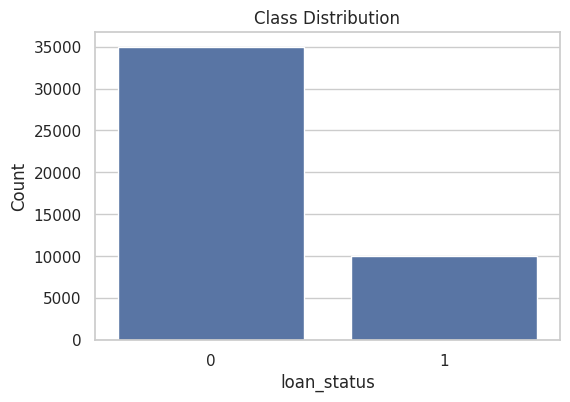

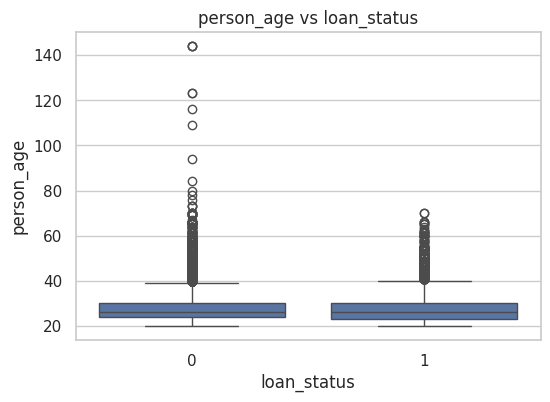

In [17]:
# TODO: Classification EDA

plt.figure(figsize=(6, 4))
sns.countplot(x=target_clf, data=df_clf)
plt.title("Class Distribution")
plt.xlabel(target_clf)
plt.ylabel("Count")
plt.show()

X_clf_full = df_clf.drop(columns=[target_clf])
num_cols_clf_full = X_clf_full.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_clf_full = X_clf_full.select_dtypes(exclude=[np.number]).columns.tolist()

if num_cols_clf_full:
    feature = num_cols_clf_full[0]
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_clf[target_clf], y=df_clf[feature])
    plt.title(f"{feature} vs {target_clf}")
    plt.xlabel(target_clf)
    plt.ylabel(feature)
    plt.show()
elif cat_cols_clf_full:
    feature = cat_cols_clf_full[0]
    top_vals = df_clf[feature].value_counts().index[:10]
    filtered = df_clf[df_clf[feature].isin(top_vals)]
    plt.figure(figsize=(8, 4))
    sns.countplot(x=feature, hue=target_clf, data=filtered)
    plt.title(f"{feature} vs {target_clf}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [18]:
# TODO: Prepare classification features

X_clf = df_clf.drop(columns=[target_clf])
y_clf = df_clf[target_clf]

num_cols_clf = X_clf.select_dtypes(include=[np.number]).columns
cat_cols_clf = X_clf.select_dtypes(exclude=[np.number]).columns

preprocess_clf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_clf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_clf),
    ],
    remainder="drop",
)

stratify_y = y_clf if y_clf.nunique() > 1 else None
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=stratify_y
)

print("Train shape:", X_train_clf.shape, "Test shape:", X_test_clf.shape)
print("Encoding + scaling prepared; split uses stratification when possible.")

Train shape: (36000, 13) Test shape: (9000, 13)
Encoding + scaling prepared; split uses stratification when possible.


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


Logistic Regression Metrics: {'Accuracy': 0.8993333333333333, 'Precision': 0.7888067581837381, 'Recall': 0.747}


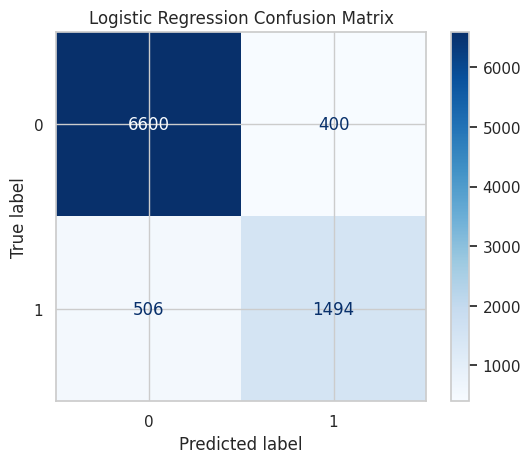

In [19]:
# TODO: Logistic Regression

def _avg_and_pos_label(y):
    if y.nunique() == 2:
        labels = sorted(y.unique())
        return "binary", labels[1]
    return "weighted", None

avg_clf, pos_label_clf = _avg_and_pos_label(y_train_clf)

log_reg_model = Pipeline(
    steps=[("preprocess", preprocess_clf), ("model", LogisticRegression(max_iter=1000))]
)
log_reg_model.fit(X_train_clf, y_train_clf)

log_pred = log_reg_model.predict(X_test_clf)
log_acc = accuracy_score(y_test_clf, log_pred)

if avg_clf == "binary":
    log_prec = precision_score(y_test_clf, log_pred, average=avg_clf, pos_label=pos_label_clf)
    log_rec = recall_score(y_test_clf, log_pred, average=avg_clf, pos_label=pos_label_clf)
else:
    log_prec = precision_score(y_test_clf, log_pred, average=avg_clf)
    log_rec = recall_score(y_test_clf, log_pred, average=avg_clf)

print("Logistic Regression Metrics:", {"Accuracy": log_acc, "Precision": log_prec, "Recall": log_rec})

ConfusionMatrixDisplay.from_predictions(y_test_clf, log_pred, cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [20]:
# TODO: SVM Classification

avg_clf, pos_label_clf = _avg_and_pos_label(y_train_clf)

svm_model = Pipeline(
    steps=[("preprocess", preprocess_clf), ("model", SVC(kernel="rbf", gamma="scale"))]
)
svm_model.fit(X_train_clf, y_train_clf)

svm_pred = svm_model.predict(X_test_clf)
svm_acc = accuracy_score(y_test_clf, svm_pred)

if avg_clf == "binary":
    svm_prec = precision_score(y_test_clf, svm_pred, average=avg_clf, pos_label=pos_label_clf)
    svm_rec = recall_score(y_test_clf, svm_pred, average=avg_clf, pos_label=pos_label_clf)
else:
    svm_prec = precision_score(y_test_clf, svm_pred, average=avg_clf)
    svm_rec = recall_score(y_test_clf, svm_pred, average=avg_clf)

print("SVM Metrics:", {"Accuracy": svm_acc, "Precision": svm_prec, "Recall": svm_rec})

SVM Metrics: {'Accuracy': 0.9177777777777778, 'Precision': 0.8575482406356413, 'Recall': 0.7555}


## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [21]:
# TODO: Naive Bayes

preprocess_nb = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_clf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_clf),
    ],
    remainder="drop",
)

to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x, accept_sparse=True
)

nb_model = Pipeline(
    steps=[("preprocess", preprocess_nb), ("to_dense", to_dense), ("model", GaussianNB())]
)
nb_model.fit(X_train_clf, y_train_clf)

nb_pred = nb_model.predict(X_test_clf)
nb_acc = accuracy_score(y_test_clf, nb_pred)

if avg_clf == "binary":
    nb_prec = precision_score(y_test_clf, nb_pred, average=avg_clf, pos_label=pos_label_clf)
    nb_rec = recall_score(y_test_clf, nb_pred, average=avg_clf, pos_label=pos_label_clf)
else:
    nb_prec = precision_score(y_test_clf, nb_pred, average=avg_clf)
    nb_rec = recall_score(y_test_clf, nb_pred, average=avg_clf)

print("Naive Bayes Metrics:", {"Accuracy": nb_acc, "Precision": nb_prec, "Recall": nb_rec})
print("Chosen variant: GaussianNB fits continuous features after scaling.")

Naive Bayes Metrics: {'Accuracy': 0.7355555555555555, 'Precision': 0.45658135283363804, 'Recall': 0.999}
Chosen variant: GaussianNB fits continuous features after scaling.


## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


KNN Accuracies: {1: 0.8763333333333333, 3: 0.8906666666666667, 5: 0.8955555555555555, 7: 0.9006666666666666, 9: 0.9011111111111111, 11: 0.9026666666666666, 13: 0.9037777777777778, 15: 0.9042222222222223}
Best K: 15


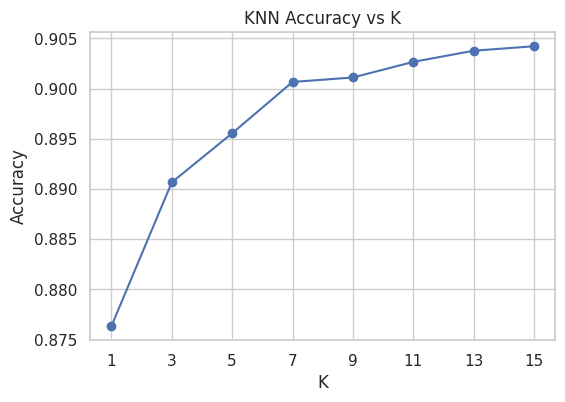

In [22]:
# TODO: KNN

k_values = list(range(1, 16, 2))
knn_accuracies = []

for k in k_values:
    knn_model = Pipeline(
        steps=[("preprocess", preprocess_clf), ("model", KNeighborsClassifier(n_neighbors=k))]
    )
    knn_model.fit(X_train_clf, y_train_clf)
    knn_pred = knn_model.predict(X_test_clf)
    knn_accuracies.append(accuracy_score(y_test_clf, knn_pred))

best_k = k_values[int(np.argmax(knn_accuracies))]
print("KNN Accuracies:", dict(zip(k_values, knn_accuracies)))
print("Best K:", best_k)

plt.figure(figsize=(6, 4))
plt.plot(k_values, knn_accuracies, marker="o")
plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.show()

## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


Random Forest Metrics: {'Accuracy': 0.9297777777777778, 'Precision': 0.8967517401392111, 'Recall': 0.773}


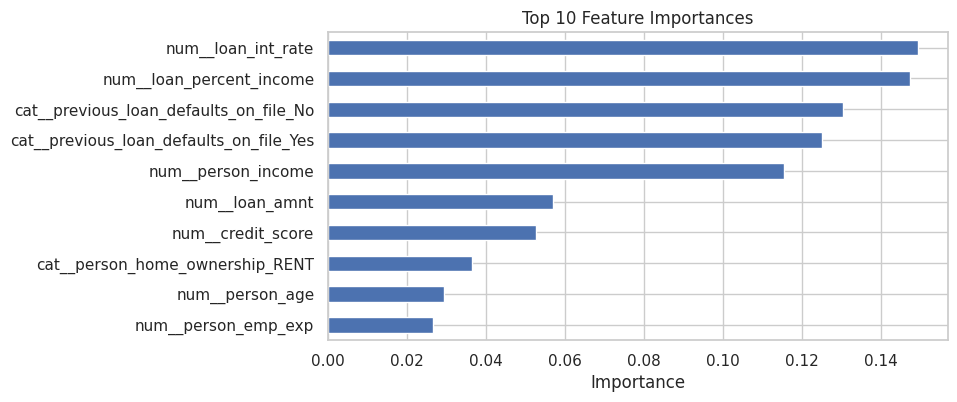

In [23]:
# TODO: Random Forest Classifier

rf_clf_model = Pipeline(
    steps=[
        ("preprocess", preprocess_clf),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42)),
    ]
)
rf_clf_model.fit(X_train_clf, y_train_clf)

rf_pred = rf_clf_model.predict(X_test_clf)
rf_acc = accuracy_score(y_test_clf, rf_pred)

if avg_clf == "binary":
    rf_prec = precision_score(y_test_clf, rf_pred, average=avg_clf, pos_label=pos_label_clf)
    rf_rec = recall_score(y_test_clf, rf_pred, average=avg_clf, pos_label=pos_label_clf)
else:
    rf_prec = precision_score(y_test_clf, rf_pred, average=avg_clf)
    rf_rec = recall_score(y_test_clf, rf_pred, average=avg_clf)

print("Random Forest Metrics:", {"Accuracy": rf_acc, "Precision": rf_prec, "Recall": rf_rec})

feature_names = rf_clf_model.named_steps["preprocess"].get_feature_names_out()
importances = rf_clf_model.named_steps["model"].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
plt.figure(figsize=(8, 4))
feat_imp.sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO: Write your reflection here